In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class ExpenseSharing:

    def __init__(self, users):
        self.users = users
        self.balance = {user: 0 for user in users}
        self.transactions = []

    # ------------------ EQUAL SPLIT ------------------
    def add_expense(self, payer, amount, participants, category):
        split = amount / len(participants)

        self.transactions.append({
            "payer": payer,
            "amount": amount,
            "participants": participants,
            "category": category
        })

        for person in participants:
            if person != payer:
                self.balance[person] += split
                self.balance[payer] -= split

    # ------------------ WEIGHTED SPLIT ------------------
    def add_weighted_expense(self, payer, amount, weights, category):
        """
        weights = {"Alice": 0.5, "Bob": 0.3, "Carol": 0.2}
        """
        self.transactions.append({
            "payer": payer,
            "amount": amount,
            "participants": list(weights.keys()),
            "category": category
        })

        for person, weight in weights.items():
            share = amount * weight
            if person != payer:
                self.balance[person] += share
                self.balance[payer] -= share

    # ------------------ REFUND ------------------
    def add_refund(self, receiver, amount, participants, category):
        split = amount / len(participants)

        self.transactions.append({
            "payer": receiver,
            "amount": -amount,
            "participants": participants,
            "category": category + "_refund"
        })

        for person in participants:
            if person != receiver:
                self.balance[person] -= split
                self.balance[receiver] += split

    # ------------------ SETTLEMENT ------------------
    def show_settlement(self):
        print("\n--- Final Settlement ---")
        for user, bal in self.balance.items():
            if bal > 0:
                print(f"{user} owes Rs. {round(bal,2)}")
            elif bal < 0:
                print(f"{user} should receive Rs. {round(-bal,2)}")
            else:
                print(f"{user} is settled")

    # ------------------Number of Payments Needed to Settle Balances Within a Group ------------------
    def simplify_debts(self):
        print("\n--- Simplified Transactions ---")

        creditors = []
        debtors = []

        for user, bal in self.balance.items():
            if bal < 0:
                creditors.append([user, -bal])
            elif bal > 0:
                debtors.append([user, bal])

        i, j = 0, 0
        while i < len(debtors) and j < len(creditors):
            debtor, debt = debtors[i]
            creditor, credit = creditors[j]

            amount = min(debt, credit)
            print(f"{debtor} pays {creditor} Rs. {round(amount,2)}")

            debtors[i][1] -= amount
            creditors[j][1] -= amount

            if debtors[i][1] == 0:
                i += 1
            if creditors[j][1] == 0:
                j += 1

    # ------------------ DATAFRAME ------------------
    def create_dataframe(self):
        data = []
        for t in self.transactions:
            split = abs(t["amount"]) / len(t["participants"])
            for p in t["participants"]:
                data.append([t["payer"], p, split, t["category"]])

        df = pd.DataFrame(data, columns=["Payer", "Participant", "Amount", "Category"])
        return df

    # ------------------ ANALYSIS ------------------
    def analysis(self):
        df = self.create_dataframe()

        print("\n--- Expense Data ---")
        print(df)

        print("\n--- Total Expense Per Person ---")
        print(df.groupby("Participant")["Amount"].sum())

        print("\n--- Expense by Category ---")
        print(df.groupby("Category")["Amount"].sum())

    # ------------------ VISUALIZATION ------------------
    def visualize(self):
        df = self.create_dataframe()

        # Bar chart
        df.groupby("Participant")["Amount"].sum().plot(kind='bar', title="Net Expense per Person")
        plt.show()

        # Pie chart
        df.groupby("Category")["Amount"].sum().plot(kind='pie', autopct='%1.1f%%')
        plt.show()





--- Final Settlement ---
Alice is settled
Bob should receive Rs. 270.0
Carol owes Rs. 270.0

--- Simplified Transactions ---
Carol pays Bob Rs. 270.0

--- Expense Data ---
   Payer Participant  Amount     Category
0  Alice       Alice   300.0         Food
1  Alice         Bob   300.0         Food
2  Alice       Carol   300.0         Food
3    Bob       Alice   200.0         Trip
4    Bob         Bob   200.0         Trip
5    Bob       Carol   200.0         Trip
6  Alice         Bob   150.0  Food_refund
7  Alice       Carol   150.0  Food_refund

--- Total Expense Per Person ---
Participant
Alice    500.0
Bob      650.0
Carol    650.0
Name: Amount, dtype: float64

--- Expense by Category ---
Category
Food           900.0
Food_refund    300.0
Trip           600.0
Name: Amount, dtype: float64


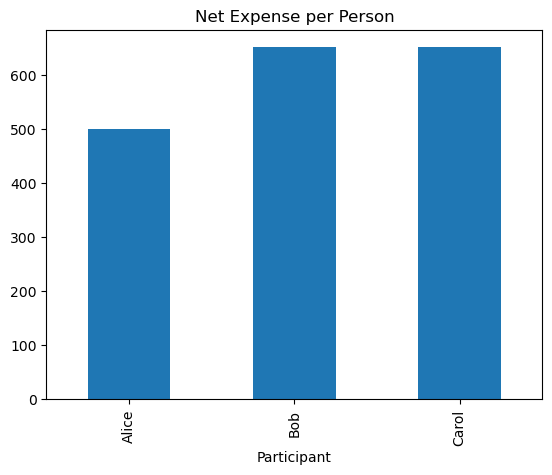

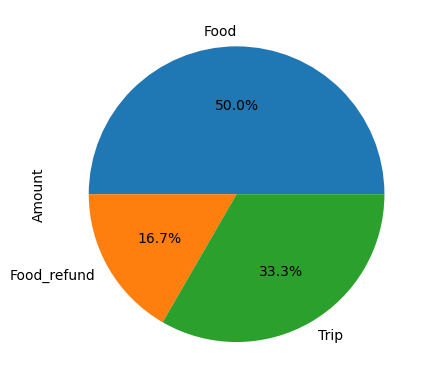

In [8]:
# ------------------ MAIN ------------------
if __name__ == "__main__":

    users = ["Alice", "Bob", "Carol"]
    app = ExpenseSharing(users)

    # dEqual split
    app.add_expense("Alice", 900, ["Alice", "Bob", "Carol"], "Food")

    # Weighted split
    app.add_weighted_expense("Bob", 600, {
        "Alice": 0.5,
        "Bob": 0.3,
        "Carol": 0.2
    }, "Trip")

    # Refund
    app.add_refund("Alice", 300, ["Bob", "Carol"], "Food")

    app.show_settlement()
    app.simplify_debts()
    app.analysis()
    app.visualize()